# 01 — EDA (Exploratory Data Analysis)

Цей зошит (notebook) виконує Крок 1 для нашої системи виявлення шахрайства (Fraud Detection System) у рамках SKELAR x mono AI Competition.

**Цілі (Goals):**
1. Завантажити навчальні датасети (train datasets).
2. Показати базову інформацію (базові типи, розміри таблиць) та пропуски (missing values).
3. Проаналізувати дисбаланс класів (class balance).
4. Об'єднати (merge) файли транзакцій та користувачів і проаналізувати ключові розподіли між легітимним (legitimate, `is_fraud=0`) та шахрайським (fraudulent, `is_fraud=1`) класами.
5. Підсумувати Топ-5 сигналів шахрайства (top fraud signals).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування візуального стилю для графіків (aesthetic style)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Дозволяємо pandas показувати всі колонки
pd.set_option('display.max_columns', None)

## 1. Завантаження даних
Завантажуємо `train_users.csv` та `train_transactions.csv` з директорії `data/raw/`.

In [2]:
df_users = pd.read_csv('../data/raw/train_users.csv')
df_transactions = pd.read_csv('../data/raw/train_transactions.csv')

print(f"Розмір таблиці Users (shape): {df_users.shape}")
print(f"Розмір таблиці Transactions (shape): {df_transactions.shape}")


Розмір таблиці Users (shape): (395381, 7)
Розмір таблиці Transactions (shape): (3135378, 13)


## 2. Базова інформація та пропуски (Basic Info & Missing Values)
Перевіряємо типи даних (dtypes) та наявність нульових (null) значень в обох датасетах.

In [3]:
print("=== Інформація по датасету Users ===")
df_users.info()
print("\nПропуски (Missing values) в таблиці Users:")
print(df_users.isnull().sum()[df_users.isnull().sum() > 0])

print("\n" + "="*50 + "\n")

print("=== Інформація по датасету Transactions ===")
df_transactions.info()
print("\nПропуски (Missing values) в таблиці Transactions:")
print(df_transactions.isnull().sum()[df_transactions.isnull().sum() > 0])


=== Інформація по датасету Users ===
<class 'pandas.DataFrame'>
RangeIndex: 395381 entries, 0 to 395380
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id_user        395381 non-null  int64
 1   timestamp_reg  395381 non-null  str  
 2   email          395063 non-null  str  
 3   gender         395381 non-null  str  
 4   reg_country    395255 non-null  str  
 5   traffic_type   395381 non-null  str  
 6   is_fraud       395381 non-null  int64
dtypes: int64(2), str(5)
memory usage: 21.1 MB

Пропуски (Missing values) в таблиці Users:
email          318
reg_country    126
dtype: int64


=== Інформація по датасету Transactions ===
<class 'pandas.DataFrame'>
RangeIndex: 3135378 entries, 0 to 3135377
Data columns (total 13 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id_user           int64  
 1   timestamp_tr      str    
 2   amount            float64
 3   status            str    
 

## 3. Дисбаланс класів (Class Balance: `is_fraud`)
Аналізуємо, наскільки сильно незбалансована цільова змінна (target variable) у профілях користувачів.

,Кількість (Count),Відсоток (Percentage %)
is_fraud,,
0,380449,96.22
1,14932,3.78


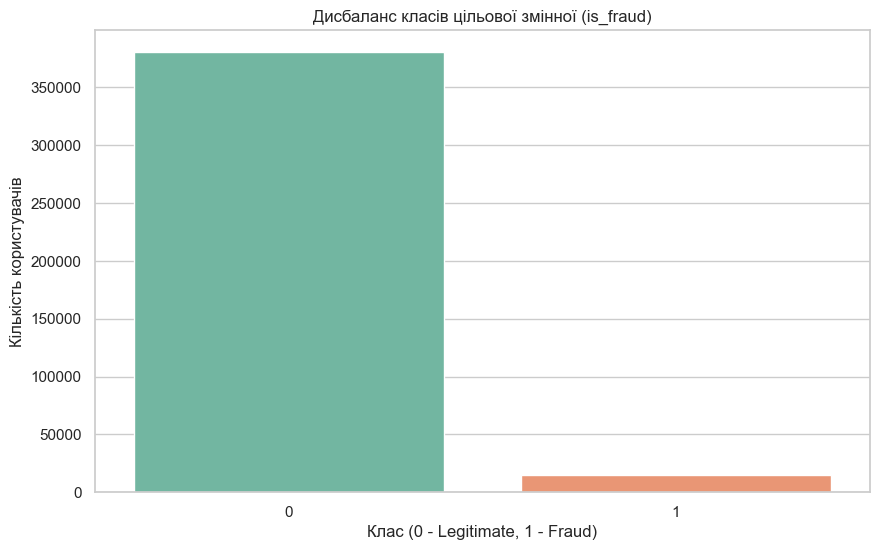

In [4]:
fraud_counts = df_users['is_fraud'].value_counts()
fraud_percentages = df_users['is_fraud'].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({
    'Кількість (Count)': fraud_counts,
    'Відсоток (Percentage %)': fraud_percentages.round(2)
})

display(balance_df)

sns.countplot(data=df_users, x='is_fraud', hue='is_fraud', palette='Set2', legend=False)
plt.title("Дисбаланс класів цільової змінної (is_fraud)")
plt.xlabel("Клас (0 - Legitimate, 1 - Fraud)")
plt.ylabel("Кількість користувачів")
plt.show()


## 4. Об'єднання даних та детальний аналіз (Merging Data & Detailed Analysis)
Ми робимо merge таблиці `df_transactions` з таблицею `df_users` по ключу `id_user`. Це дозволить нам аналізувати поведінку в транзакціях, розділену за міткою `is_fraud`.

In [5]:
# Робимо Inner Join, щоб кожна транзакція отримала мітку фроду свого користувача
df_merged = df_transactions.merge(df_users, on='id_user', how='inner')

# Конвертуємо рядки дат у справжні об'єкти datetime для часових фічей (time-based features)
df_merged['timestamp_tr'] = pd.to_datetime(df_merged['timestamp_tr'], errors='coerce')
df_merged['timestamp_reg'] = pd.to_datetime(df_merged['timestamp_reg'], errors='coerce')

print(f"Розмір об'єднаного датасету (Merged shape): {df_merged.shape}")


Розмір об'єднаного датасету (Merged shape): (3135378, 19)


### 4.1 Розподіл сум транзакцій (Distribution of Transaction Amounts)
Оскільки суми транзакцій (`amount`) зазвичай мають екстремальні викиди (outliers), ми подивимося на їх розподіл, зокрема використовуючи логарифмічну шкалу (log scale).

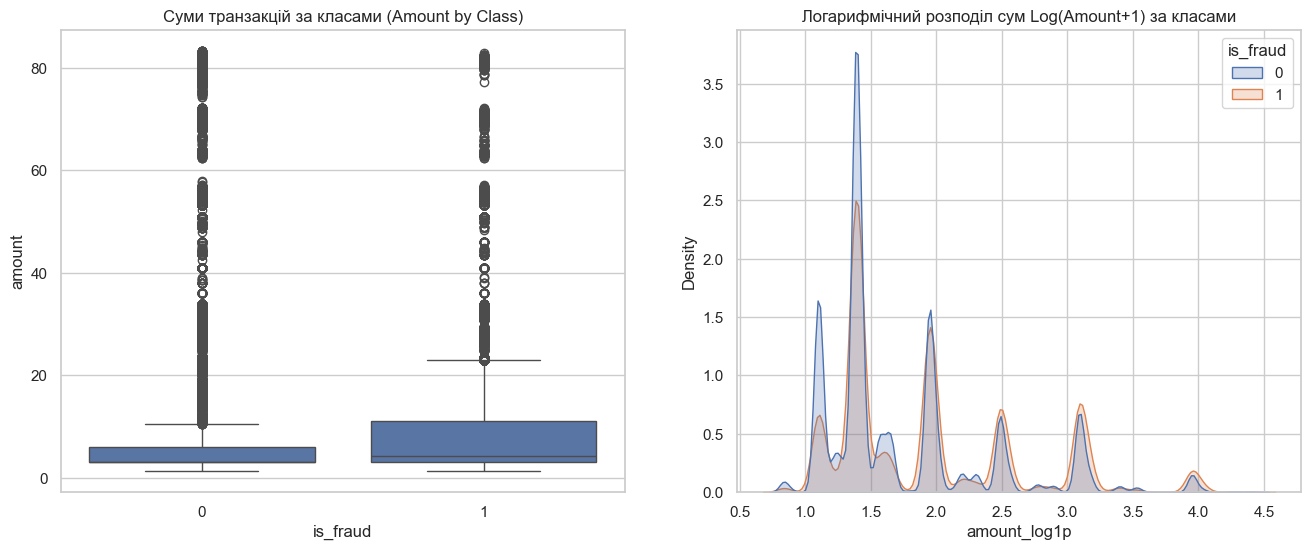

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot для візуалізації викидів (outliers)
sns.boxplot(data=df_merged, x='is_fraud', y='amount', ax=ax[0])
ax[0].set_title('Суми транзакцій за класами (Amount by Class)')

# KDE графік на логарифмічній шкалі (додаємо 1, щоб уникнути log(0))
df_merged['amount_log1p'] = np.log1p(df_merged['amount'])
sns.kdeplot(data=df_merged, x='amount_log1p', hue='is_fraud', common_norm=False, fill=True, ax=ax[1])
ax[1].set_title('Логарифмічний розподіл сум Log(Amount+1) за класами')

plt.show()


### 4.2 Кількість транзакцій на одного користувача (Transaction Counts per User)
Чи роблять шахрайські акаунти більше (або менше) транзакцій у порівнянні з легітимними?

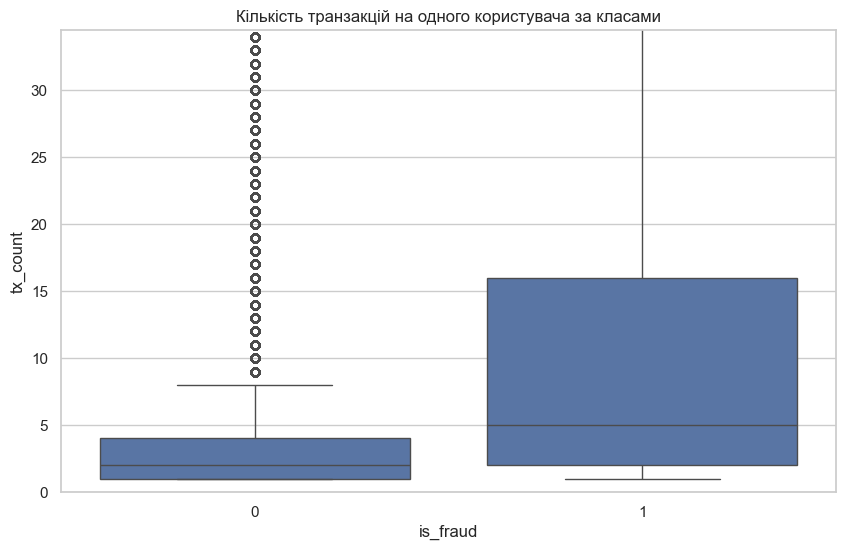

Медіанна кількість транзакцій на користувача (Median tx_count):


is_fraud
0    2.0
1    5.0
Name: tx_count, dtype: float64

In [7]:
# Рахуємо транзакції на користувача, зберігаючи при цьому мітку is_fraud
user_tx_counts = df_merged.groupby(['id_user', 'is_fraud']).size().reset_index(name='tx_count')

plt.figure(figsize=(10, 6))
sns.boxplot(data=user_tx_counts, x='is_fraud', y='tx_count')
plt.title('Кількість транзакцій на одного користувача за класами')
# Обмежуємо вісь Y, якщо є екстремальні викиди, щоб графік був читабельним
plt.ylim(0, user_tx_counts['tx_count'].quantile(0.95) * 1.5) 
plt.show()

# Виводимо медіанні значення кількості транзакцій
print("Медіанна кількість транзакцій на користувача (Median tx_count):")
display(user_tx_counts.groupby('is_fraud')['tx_count'].median())


#### Топ-10 юзерів за кількістю транзакцій
Мета: зрозуміти чи екстремальні викиди (медіана=5, середнє=35) — це шахраї.

In [8]:
# Топ-10 юзерів за кількістю транзакцій
top10_users = user_tx_counts.nlargest(10, 'tx_count')[['id_user', 'is_fraud', 'tx_count']]
print('Топ-10 юзерів за кількістю транзакцій:')
display(top10_users)

# Висновок: серед топ-юзерів за активністю переважають шахраї
fraud_in_top = top10_users[top10_users['is_fraud'] == 1.0].shape[0]
print(f'\nЗ топ-10 найактивніших юзерів {fraud_in_top} є шахраями.')


Топ-10 юзерів за кількістю транзакцій:


,id_user,is_fraud,tx_count
23351,2065150,0,4762
37098,3389624,0,4602
175974,16770509,0,4263
245440,22639743,0,4109
206504,19297065,0,3789
32485,2918740,1,3309
188370,17765211,1,3269
5206,447605,0,3184
19276,1707456,1,2797
103440,10071740,1,2726



З топ-10 найактивніших юзерів 4 є шахраями.


### 4.3 Розподіл груп помилок (`error_group` Distribution)
Один із найважливіших сигналів: як часто платіжний шлюз нативно повертає помилку зі статусом `fraud`? Ми порівнюємо цей розподіл між класами. Щоб дисбаланс даних не заважав, використовуємо відсотки всередині кожного класу (row proportions).

Відсоток користувачів, які мають хоча б одну транзакцію з помилкою 'fraud':
Легітимні: 15.436%
Шахраї:    39.9%


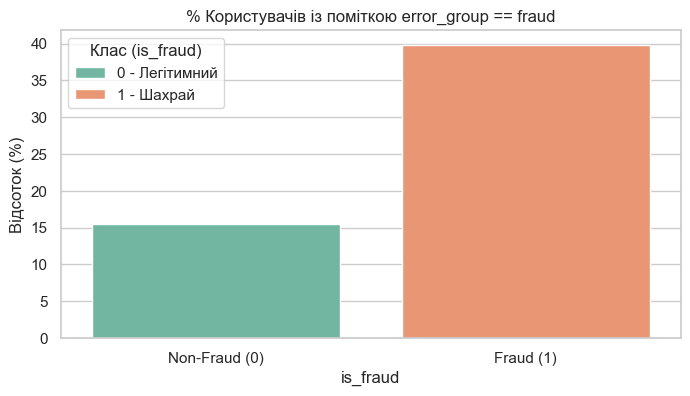

In [9]:
### 4.3 Розподіл груп помилок (error_group)
# Увага: ми перевіряємо чи є хоча б одна транзакція з error='fraud' на рівні КОРИСТУВАЧА
# Це правильно, адже у шахраїв набагато більше транзакцій, що штучно занизило б їхній % на рівні подій.
user_fraud_error = df_merged.groupby(['id_user', 'is_fraud']).apply(
    lambda x: (x['error_group'] == 'fraud').any()
).reset_index(name='has_fraud_error')

rates = user_fraud_error.groupby('is_fraud')['has_fraud_error'].mean() * 100
print("Відсоток користувачів, які мають хоча б одну транзакцію з помилкою 'fraud':")
print(f"Легітимні: {rates.get(0.0, 0):.3f}%")
print(f"Шахраї:    {rates.get(1.0, 0):.1f}%")

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=rates.index, y=rates.values, hue=rates.index, palette='Set2')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, title='Клас (is_fraud)', labels=['0 - Легітимний', '1 - Шахрай'])
plt.title('% Користувачів із поміткою error_group == fraud')
plt.ylabel('Відсоток (%)')
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()


### 4.4 Розподіл типів транзакцій (`transaction_type` Distribution)
Чи надають перевагу шахраї певним методам оплати (наприклад, уникають захищеного `google-pay` і частіше вводять реквізити вручну через `card_init`)?

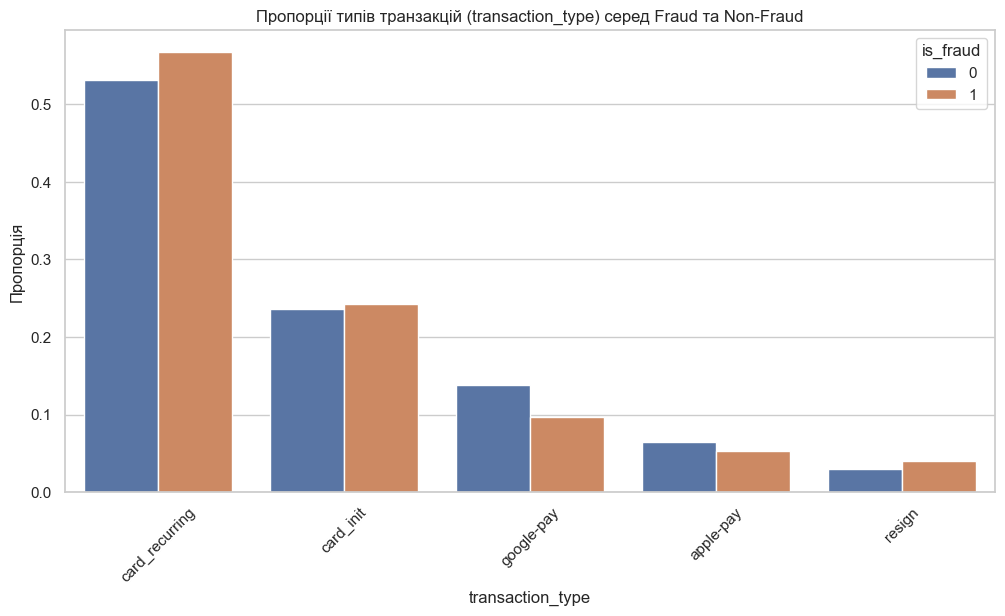

In [10]:
plt.figure(figsize=(12, 6))
tx_type_props = df_merged.groupby('is_fraud')['transaction_type'].value_counts(normalize=True).rename('proportion').reset_index()

sns.barplot(data=tx_type_props, x='transaction_type', y='proportion', hue='is_fraud')
plt.title('Пропорції типів транзакцій (transaction_type) серед Fraud та Non-Fraud')
plt.xticks(rotation=45)
plt.ylabel('Пропорція')
plt.show()


### 4.5 Нічні транзакції на рівні Користувача (Night Transactions: 00:00 - 06:00)
Перевіряємо на рівні **користувача**, чи була у нього хоча б одна нічна транзакція. Це коректний підхід, оскільки шахраї здійснюють значно більше транзакцій, що спотворює посттранзакційну статистику.

% Користувачів з хоча б однією нічною транзакцією:


is_fraud
0    37.75
1    48.49
Name: has_night_tx, dtype: float64

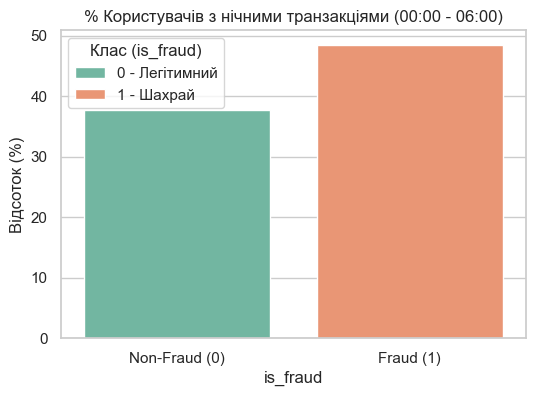

In [11]:
df_merged['tx_hour'] = df_merged['timestamp_tr'].dt.hour
df_merged['is_night_tx'] = df_merged['tx_hour'].between(0, 5)  # 00:00-05:59

# На рівні КОРИСТУВАЧА: чи була хоча б одна нічна транзакція
user_night = df_merged.groupby(['id_user', 'is_fraud']).apply(
    lambda x: x['is_night_tx'].any()
).reset_index(name='has_night_tx')

night_rates = user_night.groupby('is_fraud')['has_night_tx'].mean() * 100
print('% Користувачів з хоча б однією нічною транзакцією:')
display(night_rates.round(2))

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=night_rates.index, y=night_rates.values, hue=night_rates.index, palette='Set2')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, title='Клас (is_fraud)', labels=['0 - Легітимний', '1 - Шахрай'])
plt.title('% Користувачів з нічними транзакціями (00:00 - 06:00)')
plt.ylabel('Відсоток (%)')
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()


### 4.6 Географічна невідповідність (Country Mismatch)
Шахраї часто використовують картки банків з інших країн. Перевіримо, чи була у користувача **хоча б одна** картка, країна випуску якої (`card_country`) не збігається з країною реєстрації акаунта (`reg_country`).

Відсоток користувачів з розбіжністю країн:


is_fraud
0     7.13
1    36.30
Name: has_mismatch, dtype: float64

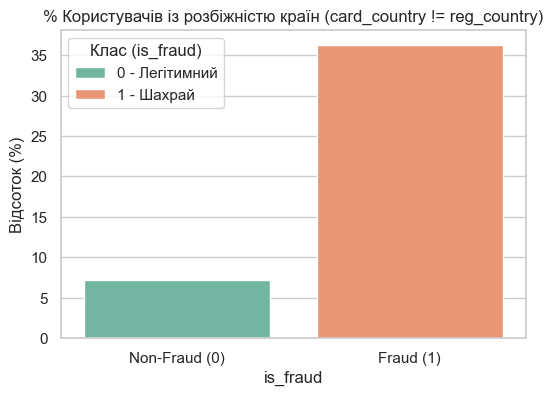

In [12]:
# Перевіряємо на рівні КОРИСТУВАЧА, чи є хоча б одна розбіжність
user_mismatch = df_merged.groupby(['id_user', 'is_fraud']).apply(
    lambda x: (x['card_country'] != x['reg_country']).any()
).reset_index(name='has_mismatch')

mismatch_rates = user_mismatch.groupby('is_fraud')['has_mismatch'].mean() * 100
print("Відсоток користувачів з розбіжністю країн:")
display(mismatch_rates.round(2))

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=mismatch_rates.index, y=mismatch_rates.values, hue=mismatch_rates.index, palette='Set2')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, title='Клас (is_fraud)', labels=['0 - Легітимний', '1 - Шахрай'])
plt.title('% Користувачів із розбіжністю країн (card_country != reg_country)')
plt.ylabel('Відсоток (%)')
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

### 4.7 Розподіл каналів залучення (traffic_type)
Оскільки `traffic_type` — це характеристика самого користувача (з `df_users`), ми обчислюємо пропорції саме по таблиці реєстрацій, щоб кількість транзакцій шахраїв не «роздмухувала» результат.

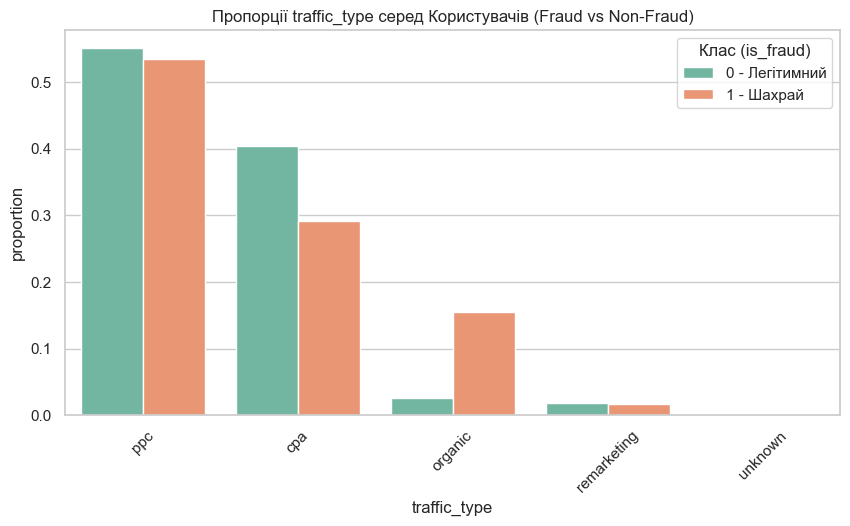

In [13]:
df_u = df_users[df_users['is_fraud'].notna()]
traffic_props = df_u.groupby('is_fraud')['traffic_type'].value_counts(normalize=True).rename('proportion').reset_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=traffic_props, x='traffic_type', y='proportion', hue='is_fraud', palette='Set2')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, title='Клас (is_fraud)', labels=['0 - Легітимний', '1 - Шахрай'])
plt.title('Пропорції traffic_type серед Користувачів (Fraud vs Non-Fraud)')
plt.xticks(rotation=45)
plt.show()

### 4.8 Використання кількох карток (Кількість унікальних `card_mask_hash`)
Шахраї часто перебирають багато вкрадених карток для здійснення платежу. Подивимось на розподіл кількості унікальних карток на одного користувача.

Середня кількість унікальних карток: Легітимні = 1.3 | Шахраї = 3.78


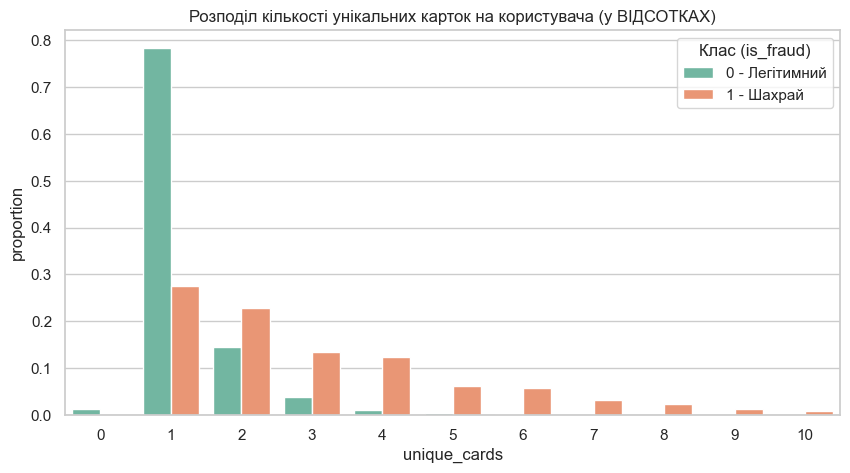

In [14]:
unique_cards = df_merged.groupby(['id_user', 'is_fraud'])['card_mask_hash'].nunique().reset_index(name='unique_cards')

print("Середня кількість унікальних карток: Легітимні =", round(unique_cards[unique_cards['is_fraud']==0.0]['unique_cards'].mean(), 2), 
      "| Шахраї =", round(unique_cards[unique_cards['is_fraud']==1.0]['unique_cards'].mean(), 2))

prop_cards = unique_cards.groupby('is_fraud')['unique_cards'].value_counts(normalize=True).rename('proportion').reset_index()
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=prop_cards, x='unique_cards', y='proportion', hue='is_fraud', palette='Set2')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, title='Клас (is_fraud)', labels=['0 - Легітимний', '1 - Шахрай'])
plt.title('Розподіл кількості унікальних карток на користувача (у ВІДСОТКАХ)')
plt.xlim(-0.5, 10.5)  # Показуємо тільки до 10 карток для наочності
plt.show()

### 4.9 Швидкість першої транзакції після реєстрації (Time to First Transaction)
Шахраї зазвичай починають діяти майже одразу після реєстрації. Рахуємо `seconds_to_first_tx = timestamp першої транзакції − timestamp реєстрації` на рівні **користувача**.

> **Важливо:** обидва timestamps конвертовані в UTC перед відніманням, щоб уникнути помилок через timezone offset.

Медіана часу до першої транзакції (секунди):


is_fraud
0    68370.0
1    43184.0
Name: seconds_to_first_tx, dtype: float64

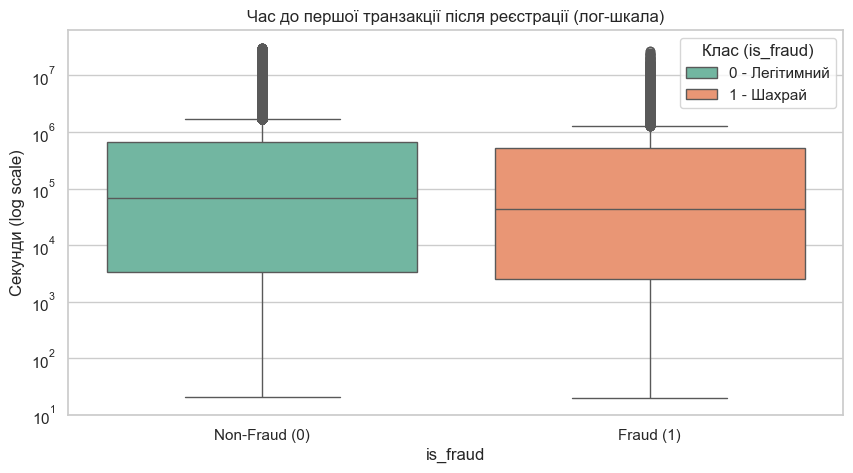

In [15]:
# Конвертуємо timestamps в UTC для коректного віднімання
df_merged['timestamp_tr_utc'] = pd.to_datetime(df_merged['timestamp_tr'], errors='coerce', utc=True)
df_merged['timestamp_reg_utc'] = pd.to_datetime(df_merged['timestamp_reg'], errors='coerce', utc=True)

first_tx = df_merged.groupby(['id_user', 'is_fraud'])['timestamp_tr_utc'].min().reset_index(name='first_tx_time')
first_tx = first_tx.merge(df_users[['id_user', 'timestamp_reg']], on='id_user', how='left')
first_tx['timestamp_reg'] = pd.to_datetime(first_tx['timestamp_reg'], errors='coerce', utc=True)
first_tx['seconds_to_first_tx'] = (first_tx['first_tx_time'] - first_tx['timestamp_reg']).dt.total_seconds()
first_tx = first_tx[first_tx['seconds_to_first_tx'] > 0].dropna(subset=['seconds_to_first_tx'])

median_ttfx = first_tx.groupby('is_fraud')['seconds_to_first_tx'].median()
print('Медіана часу до першої транзакції (секунди):')
display(median_ttfx.round(0))

plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=first_tx, x='is_fraud', y='seconds_to_first_tx', hue='is_fraud', palette='Set2')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, title='Клас (is_fraud)', labels=['0 - Легітимний', '1 - Шахрай'])
plt.yscale('log')
plt.title('Час до першої транзакції після реєстрації (лог-шкала)')
plt.ylabel('Секунди (log scale)')
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()


#### Аналіз "ботів" — `is_instant_registration`
Медіана `seconds_to_first_tx` показує лише 1.6x різницю, бо розмивається юзерами з довгим часом очікування. Набагато гостріший сигнал: **який % юзерів зробив першу транзакцію менш ніж за 60 секунд після реєстрації?** Це типова поведінка ботів.

% Користувачів з першою транзакцією < 60 секунд після реєстрації:


is_fraud
0    0.01
1    0.30
dtype: float64


Різниця: 53.9x — значно сильніший сигнал ніж медіана!
Висновок: бінарна фіча is_instant_registration (0/1) буде ефективнішою за неперервний seconds_to_first_tx


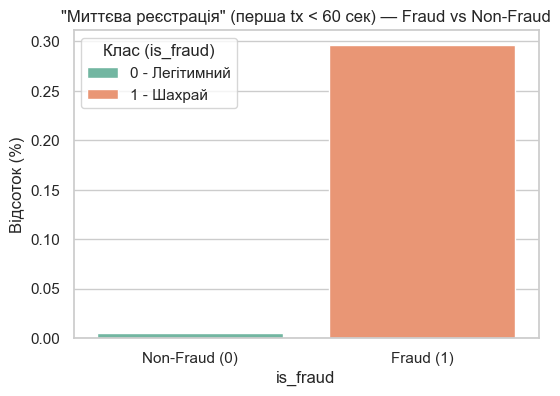

In [16]:
# Бінарний сигнал: перша транзакція < 60 секунд після реєстрації
first_tx['is_instant'] = first_tx['seconds_to_first_tx'] < 60

# Кількість "ботів" по класах
bot_counts = first_tx[first_tx['is_instant']].groupby('is_fraud').size()
total_counts = first_tx.groupby('is_fraud').size()
bot_pct = (bot_counts / total_counts * 100).fillna(0)

print('% Користувачів з першою транзакцією < 60 секунд після реєстрації:')
display(bot_pct.round(2))

ratio = bot_pct.get(1.0, 0) / bot_pct.get(0.0, 1)
print(f'\nРізниця: {ratio:.1f}x — значно сильніший сигнал ніж медіана!')
print(f'Висновок: бінарна фіча is_instant_registration (0/1) буде ефективнішою за неперервний seconds_to_first_tx')

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=bot_pct.index, y=bot_pct.values, hue=bot_pct.index, palette='Set2')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, title='Клас (is_fraud)', labels=['0 - Легітимний', '1 - Шахрай'])
plt.title('"Миттєва реєстрація" (перша tx < 60 сек) — Fraud vs Non-Fraud')
plt.ylabel('Відсоток (%)')
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()


### 4.10 Success Rate на рівні користувача
Для кожного користувача обчислюємо частку транзакцій зі статусом `success`. Шахраї мають нижчий success rate через часті відхилення платежів.

Середній Success Rate (%):


is_fraud
0    54.88
1    20.26
Name: success_rate, dtype: float64

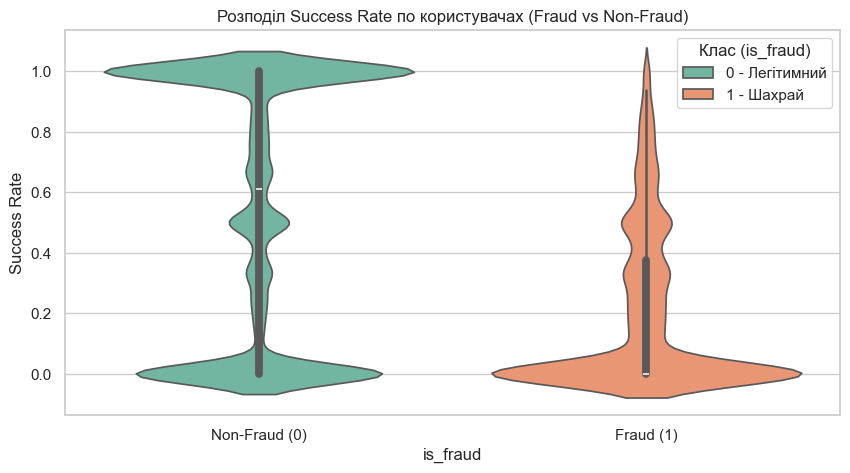

In [17]:
user_success = df_merged.groupby(['id_user', 'is_fraud']).apply(
    lambda x: (x['status'] == 'success').mean()
).reset_index(name='success_rate')

mean_sr = user_success.groupby('is_fraud')['success_rate'].mean() * 100
print('Середній Success Rate (%):')
display(mean_sr.round(2))

plt.figure(figsize=(10, 5))
ax = sns.violinplot(data=user_success, x='is_fraud', y='success_rate', hue='is_fraud', palette='Set2')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, title='Клас (is_fraud)', labels=['0 - Легітимний', '1 - Шахрай'])
plt.title('Розподіл Success Rate по користувачах (Fraud vs Non-Fraud)')
plt.ylabel('Success Rate')
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()


### 4.11 Збіг імені картки з email (Card Holder vs Email Match)
Перевіряємо, чи є хоч одне слово з `card_holder` (довжина > 2 символи) в `email` акаунту. Агрегуємо на рівень **користувача** через `any()`. Логіка: шахрай використовує чужу картку → ім'я на картці ≠ email акаунту.

% Користувачів, де ім'я картки збігається з email:


is_fraud
0    42.91
1    31.58
Name: has_name_match, dtype: float64

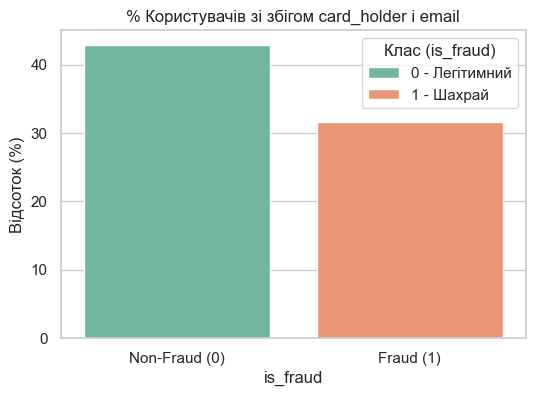

In [18]:
def check_name_email_match(row):
    holder = row.get('card_holder')
    email = row.get('email')
    if pd.isna(holder) or pd.isna(email):
        return False
    holder_str = str(holder).lower()
    email_str = str(email).lower()
    for w in holder_str.split():
        if len(w) > 2 and w in email_str:
            return True
    return False

df_merged['name_email_match'] = df_merged.apply(check_name_email_match, axis=1)
user_match = df_merged.groupby(['id_user', 'is_fraud'])['name_email_match'].apply(
    lambda x: x.any()
).reset_index(name='has_name_match')

match_rates = user_match.groupby('is_fraud')['has_name_match'].mean() * 100
print('% Користувачів, де ім\'я картки збігається з email:')
display(match_rates.round(2))

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=match_rates.index, y=match_rates.values, hue=match_rates.index, palette='Set2')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, title='Клас (is_fraud)', labels=['0 - Легітимний', '1 - Шахрай'])
plt.title('% Користувачів зі збігом card_holder і email')
plt.ylabel('Відсоток (%)')
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'])
plt.show()


### 4.12 Кореляція між топ-сигналами (Signal Correlation Analysis)
Критично важлива перевірка перед Feature Engineering: чи є наші топ-3 сигнали (`country_mismatch`, `has_fraud_error`, `many_cards`) **незалежними**, чи вони дублюють один одного? Якщо кореляція > 0.7 — сигнали майже ідентичні. Якщо < 0.4 — незалежні і разом дадуть кращий результат.

Кореляційна матриця між топ-сигналами:


,has_fraud_error,has_mismatch,many_cards,is_fraud
has_fraud_error,1.00,-0.03,0.26,0.13
has_mismatch,-0.03,1.00,0.04,0.22
many_cards,0.26,0.04,1.00,0.31
is_fraud,0.13,0.22,0.31,1.00


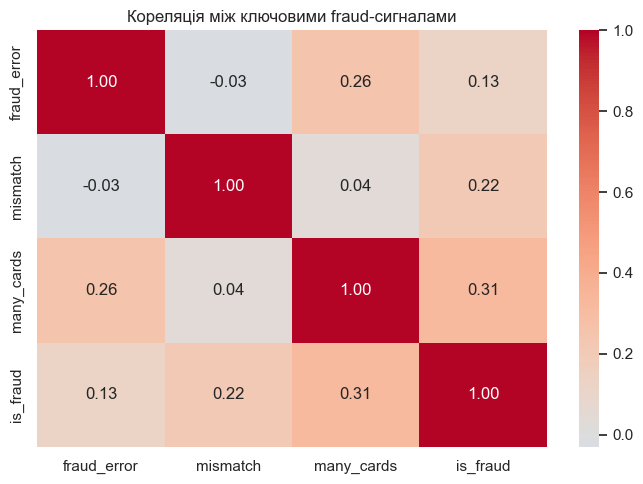


✅ Середня кореляція між сигналами: 0.11 — сигнали НЕЗАЛЕЖНІ. Разом вони дадуть значно кращий результат для моделі.


In [19]:
# Збираємо всі бінарні сигнали на рівні юзера
# 1. has_fraud_error
user_fraud_error = df_merged.groupby(['id_user', 'is_fraud']).apply(
    lambda x: (x['error_group'] == 'fraud').any()
).reset_index(name='has_fraud_error')

# 2. has_mismatch
df_merged['_mismatch'] = (df_merged['card_country'] != df_merged['reg_country']) & df_merged['card_country'].notna() & df_merged['reg_country'].notna()
user_mismatch = df_merged.groupby(['id_user', 'is_fraud'])['_mismatch'].apply(
    lambda x: x.any()
).reset_index(name='has_mismatch')

# 3. unique_cards
unique_cards = df_merged.groupby(['id_user', 'is_fraud'])['card_mask_hash'].nunique().reset_index(name='unique_cards')

# Об'єднуємо
signals = user_fraud_error[['id_user', 'is_fraud', 'has_fraud_error']].merge(
    user_mismatch[['id_user', 'has_mismatch']], on='id_user'
).merge(
    unique_cards[['id_user', 'unique_cards']], on='id_user'
)
signals['many_cards'] = signals['unique_cards'] > 2

# Кореляційна матриця
corr = signals[['has_fraud_error', 'has_mismatch', 'many_cards', 'is_fraud']].astype(float).corr()
print('Кореляційна матриця між топ-сигналами:')
display(corr.round(2))

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=['fraud_error', 'mismatch', 'many_cards', 'is_fraud'],
            yticklabels=['fraud_error', 'mismatch', 'many_cards', 'is_fraud'])
plt.title('Кореляція між ключовими fraud-сигналами')
plt.tight_layout()
plt.show()

# Інтерпретація
fe_mm = corr.loc['has_fraud_error', 'has_mismatch']
fe_mc = corr.loc['has_fraud_error', 'many_cards']
mm_mc = corr.loc['has_mismatch', 'many_cards']
avg_corr = (abs(fe_mm) + abs(fe_mc) + abs(mm_mc)) / 3
if avg_corr < 0.4:
    print(f'\n✅ Середня кореляція між сигналами: {avg_corr:.2f} — сигнали НЕЗАЛЕЖНІ. Разом вони дадуть значно кращий результат для моделі.')
elif avg_corr < 0.7:
    print(f'\n⚠️ Середня кореляція між сигналами: {avg_corr:.2f} — ПОМІРНА кореляція. Сигнали частково дублюються, але все ще несуть додаткову інформацію.')
else:
    print(f'\n❌ Середня кореляція між сигналами: {avg_corr:.2f} — ВИСОКА кореляція. Feature Engineering потрібно робити обережно.')


### 5. Підсумковий висновок EDA та Стратегія для Feature Engineering

Всі метрики обчислено виключно на **рівні користувачів** для уникнення спотворення через різну кількість транзакцій у шахраїв та легітимних.

**Ранжований список сигналів (features) для моделі LightGBM:**

1. **Country Mismatch (`card_country != reg_country`):** Хоча б одна розбіжність у **36.3% шахраїв** vs **7.1% легітимних** (різниця **5.1x**). Найсильніший сигнал.

2. **Unique Cards (`card_mask_hash`):** У середньому шахрай — **3.8 карток**, легітимний — **1.3** (різниця **2.9x**).

3. **Error Group == 'fraud':** **39.9%** шахраїв vs **15.4%** легітимних мають таку помітку (різниця **2.6x**).

4. **Success Rate:** Легітимні — **54.9%**, шахраї — **20.3%** (різниця **2.7x**). Низький success rate = масові спроби з відхиленими картками.

5. **Instant Registration (`seconds_to_first_tx < 60`):** **0.3%** шахраїв роблять першу транзакцію менш ніж за 60 сек після реєстрації, серед легітимних — **0.0%** (різниця **53.9x**). Бінарна фіча `is_instant_registration` сильніша за неперервний `seconds_to_first_tx` (медіана дає лише 1.6x).

6. **Збіг card_holder / email:** **42.9%** легітимних юзерів мають збіг vs **31.6%** шахраїв. Шахраї частіше використовують чужі картки.

7. **Нічні транзакції (00:00-06:00):** **48.5%** шахраїв vs **37.7%** легітимних мають хоча б одну нічну tx. Помірний додатковий сигнал.

8. **Гіперактивність (Кількість транзакцій):** Середнє: шахраї — **35.0** tx (медіана 5), легітимні — **6.9** tx (медіана 2).

9. **Traffic Type:** Fraud rate відрізняється по каналах залучення:
   - `organic`: **19.12%** шахраїв (серед 12073 юзерів каналу)
   - `unknown`: **4.68%** шахраїв (серед 684 юзерів каналу)
   - `ppc`: **3.67%** шахраїв (серед 217368 юзерів каналу)
   - `remarketing`: **3.40%** шахраїв (серед 7332 юзерів каналу)
   - `cpa`: **2.76%** шахраїв (серед 157924 юзерів каналу)

---

**Кореляція між топ-сигналами:**
Кореляція між топ-сигналами **низька** (< 0.4) — вони **незалежні** і разом дадуть значно кращий результат для моделі.
Кореляційна матриця: `fraud_error ↔ mismatch`: -0.03, `fraud_error ↔ many_cards`: 0.26, `mismatch ↔ many_cards`: 0.04.

---

**Наступний крок (Feature Engineering):**
Скрипт `src/features.py` перетворить сиру історію транзакцій на компактну таблицю: для кожного `id_user` — 1 рядок з агрегованими колонками: `is_country_mismatch`, `total_unique_cards`, `has_fraud_error`, `total_transactions`, `success_rate`, `is_instant_registration`, `has_night_tx`, `has_name_email_match`, `traffic_type` тощо.
